## <img src="logo_UNSAM.jpg" align="right" width="300" height="300"> *Análisis y precesamiento de señales*  
<h3 style="font-weight: normal;">Alumno: Joaquín Rios</h3>
&nbsp;
&nbsp;

## |  Trabajo Semanal N°1




&emsp;&emsp;&emsp; El objetivo de este trabajo es describir los fenómenos que vemos al generar distintas señales con una cantidad $N = 1000$  de muestras y luego aplicándole su transformada de Fourier. Las señales que trabajaremos deberán tener ciertos parámetros fijos pero veremos cómo cambiará la forma de esta y cómo le afecta el ruido. Dejaremos de lado la fase de la señal y veremos únicaente el módulo de su **Transformada de Fourier** para ver cómo se comporta.

&emsp;&emsp;&emsp; En esta oportunidad los parámetros los definimos como:
- El Duty Cycle de la señal (%)
- La potencia media de la señal (Watts)
- La frecuencia (Hz)
- La fase (radianes)
- La cantidad de muestras digitalizada por el ADC (# muestras)


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

N=1000
vmax = 1
Ps = 2
ff=2000
MpP = 10 #Muestras por período
ph = 0
dc=0
fs = ff*MpP*10
nn = np.arange(N)
#Para hallar la cant. de muestras tengo que ver fs/f y luego f*muestras que quiero
#Ahora vamos a ver 100 muestras por período por el *10
#k = 10
k=10 #K siendo la cantidad de períodos que me entran en la N cantidad de muestras 

&emsp;&emsp;&emsp; Una vez definidos los parámetros vamos construyendo las señales pedidas  y visualiando que sucede en su espectro de frecuencias (la representación de su transformada). 



#### ->  1. Senoidal de 2 KHz 
&emsp;&emsp;&emsp; Probamos con una senoidal **Sin Ruido** con  $Muestras  Por  Período = 100$ &emsp; Vemos primero su representación
en el eje temporal, y luego en el eje de frecuencias.

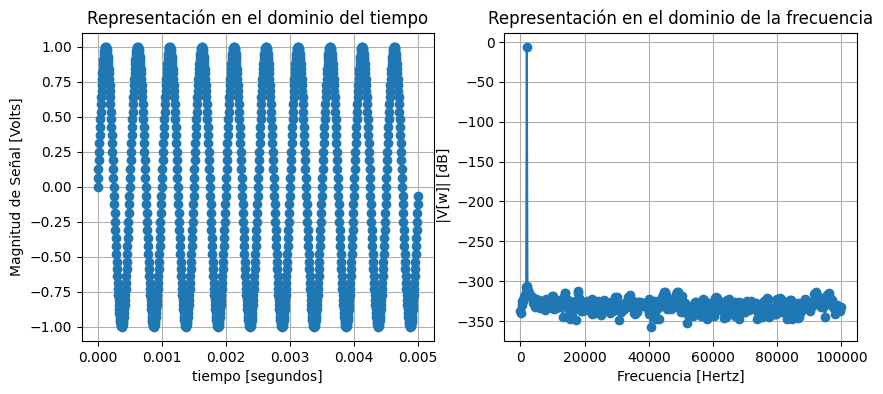

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
#Parte Temporal
vmax = 1
k=10
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

ax1.plot(tt, xx, 'o-')
ax1.set_title("Representación en el dominio del tiempo")
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.grid(True)

#Parte frecuencial
fftxx = fft(xx)
fftxx = fftxx[:N//2]
fftxx_abs = np.abs(fftxx) /N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


ax2.plot(freq, 20*np.log10(fftxx_abs), 'o-')
ax2.set_title("Representación en el dominio de la frecuencia")
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel(" |V[w]| [dB]")
ax2.grid(True)

plt.show()

&emsp;&emsp;&emsp; Lo que vemos acá es muy interesante, ya que a pesar de no contar con ruido sumado a la señal, vemos un "piso ruidoso" 
el cual se da por los valores pequeñísimas de error computacional que tiene la transformada de fourier, y se ven cercanos ya que se usó una escala 
logaritmica para visualizar mejor el pico, si se hacen los cálculos una señal de $-350dB$ es prácticamente 0. Vemos además que al tener una potencia de $1 Watt$ obtenemos en el gráfico de frecuencias una amplitud de $0 dB$, Esto ya que se normalizó todo el espectro por $\frac{1}{N}$, esto se deriva de la expresión de la DFT la cual es una suma de  N muestras, y en cada suma el valor del pico de la FFT crece proporcionalmente con N. Un parámetro importante a la hora de construir estas señales es el factor *k*, ya que si este no fuese entero la energía puntual que vemos en este ejemplo ya no sería de esta forma, al no ser múltiplo entero de la resolución espectral observamos que la energía no cae solo en un casillero sino que caerá en secciones adyacentes.

#### ->  2. Senoidal de 2 watt y desfasada 
&emsp;&emsp;&emsp; Probamos con una senoidal **Sin Ruido** con  $Phase = \frac{π}{2}$ y cuya potencia media será de $Potencia = 2$ &emsp; Vemos primero su representación
en el eje temporal, y luego en el eje de frecuencias.

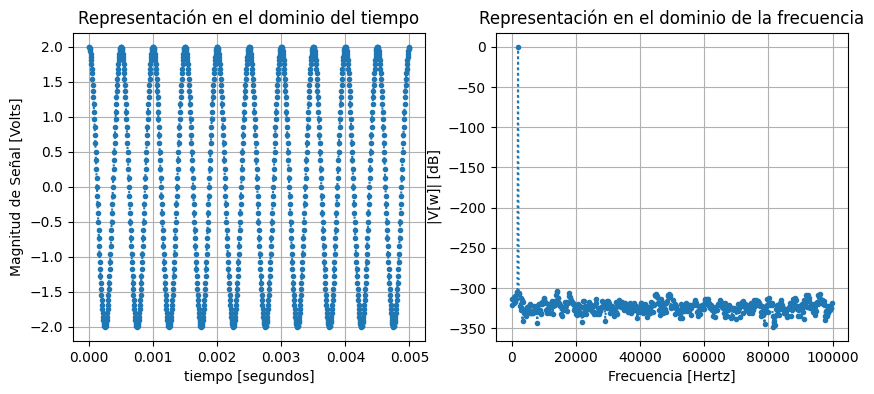

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
#Parte Temporal
vmax= np.sqrt(2*Ps)
ph = (np.pi)/2
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

ax1.plot(tt, xx, ':.')
ax1.set_title("Representación en el dominio del tiempo")
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.grid(True)

#Parte frecuencial
fftxx = fft(xx)
fftxx = fftxx[:N//2]
fftxx_abs = np.abs(fftxx)/N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


ax2.plot(freq, 20*np.log10(fftxx_abs), ':.')
ax2.set_title("Representación en el dominio de la frecuencia")
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel("|V[w]| [dB]")
ax2.grid(True)

plt.show()

&emsp;&emsp;&emsp; No es extraño ver que, aunque estamos modificando la fase de nuestra senoidal, no se observe un cambio significativo en el gráfico referido a las frecuencias, esto ya que solo estamos viendo el valor del módulo de la transformada, y no la fase de esta, por lo que es lógico ver el mismo gráfico. Se destaca que al estar desfasando la senoide en $\frac{π}{2}$ obtenemos un coseno como resultado. Pero lo único notable en este caso es que al aumentar la amplitud en Volts, se ve un aumento significativo en la escala de la segunda figura, pareciendo que el ruido computacional es menor, pero no es así.

#### ->  3. Senoidal con ruido normalmente distribuido
&emsp;&emsp;&emsp; Probamos con una senoidal **con Ruido** en este apartado, mantenemos los parámetros anteriors, salvo el desfasaje, y sumamos una señal ruidosa  $Pr = 0.1 W$ &emsp; Vemos primero su representación
en el eje temporal, y luego en el eje de frecuencias como en los ejemplos anteriores.

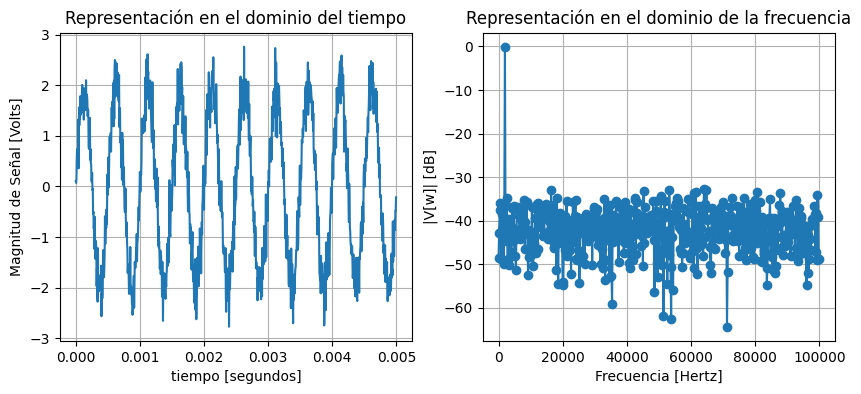

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
#Parte Temporal
vmax= np.sqrt(2*Ps)
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

sigma = np.sqrt(0.1) #La potencia del ruido normal es la raiz de la desviacion estandar
rr = np.random.normal(0,sigma,size=len(tt))

zz= xx+rr


ax1.plot(tt, zz)
ax1.set_title("Representación en el dominio del tiempo")
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.grid(True)

#Parte frecuencial
fftxx = fft(zz)
fftxx = fftxx[:N//2]
fftxx_abs = np.abs(fftxx)/N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


ax2.plot(freq, 20*np.log10(fftxx_abs), 'o-')
ax2.set_title("Representación en el dominio de la frecuencia")
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel("|V[w]| [dB]")
ax2.grid(True)

plt.show()

&emsp;&emsp;&emsp; Notamos a simple viste que la senoide que se vió en las muestras anteriores en este caso se ve como corrupta si se quiere, con picos más altos que otros y con deformaciones en los valores que toma entre cada ciclo. Este fenómeno se da porque a la señal original se le suma un ruido que en este caso tiene una distribución normal. Al analizar detenidamente el gráfico, vemos que la energía del ruido parece distribuirse de manera uniforme por todo el espectro, habiendo picos negativos de $-70B$. Bajo esta premisa podemos decir que parece que el "piso de ruido" visto en las senoides anteriores pareció subir, y con una amplitud considerable, provocando que empeore drásticamente la relación Señal/ruido.

#### ->  4. Senoidal con ruido uniformemente distribuido
&emsp;&emsp;&emsp; Probamos con una senoidal **con Ruido** en este apartado, mantenemos los parámetros anteriors, salvo el desfasaje, y sumamos una señal ruidosa  $Pr = 0.1 W$ como el anterior a este. &emsp; Vemos primero su representación
en el eje temporal, y luego en el eje de frecuencias.

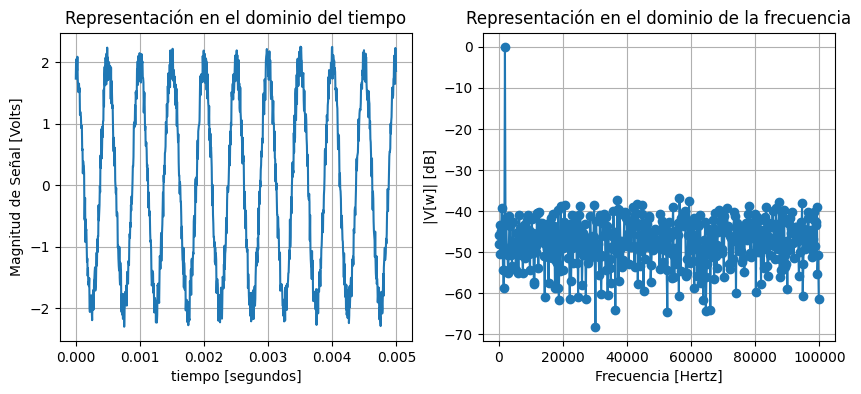

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
#Parte Temporal
vmax= np.sqrt(2*Ps)
xx = vmax * np.sin(2*np.pi*(k*fs/N)*(nn/fs) + ph)
tt= np.arange(0,N)/fs

sigma = np.sqrt(0.1) #La potencia del ruido normal es la raiz de la desviacion estandar
rr = np.random.uniform(-sigma, sigma, size=len(tt))

zz= xx+rr


ax1.plot(tt, zz)
ax1.set_title("Representación en el dominio del tiempo")
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.grid(True)

#Parte frecuencial
fftxx = fft(zz)
fftxx = fftxx[:N//2]
fftxx_abs = np.abs(fftxx)/N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


ax2.plot(freq, 20*np.log10(fftxx_abs), 'o-')
ax2.set_title("Representación en el dominio de la frecuencia")
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel("|V[w]| [dB]")
ax2.grid(True)

plt.show()

&emsp;&emsp;&emsp; Hay un cambio con respecto al anterior, la señal se ve (o eso parece) menos ruidosa, a pesar de tener la misma potencia de ruido, esto nos indica que depende del tipo de ruido tendremos una mejor o peor visualización de la señal, a pesar de tener la misma relación señal ruido. Lo corroboramos con el espectro, donde vemos que parece mantenerse en un piso de $-40dB$. 

#### ->  5. Tren de pulsos
&emsp;&emsp;&emsp; Es un tren de pulsos con un $Duty Cycle = 0.5$ con la misma frecuencia y con una potencia de $1 Watt$.

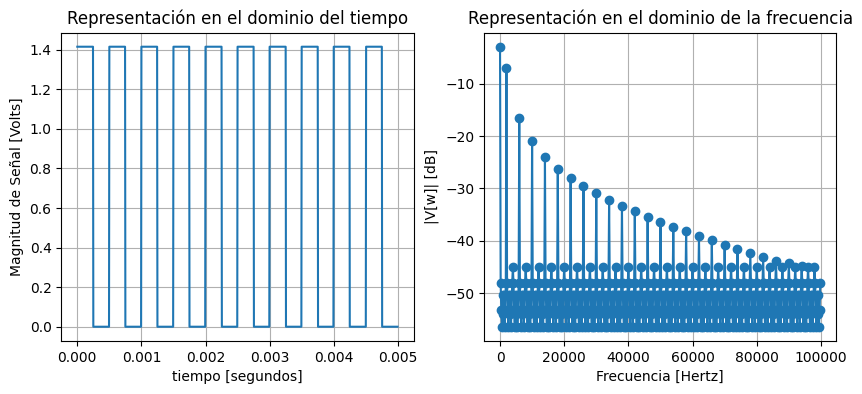

In [64]:
from scipy.signal import square
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

D = 0.5

tt= np.arange(0,N)/fs

Vmax = np.sqrt(2)

xx = Vmax * (square(2*np.pi*ff*tt, duty=D) + 1)/2

ax1.plot(tt, xx)
ax1.set_title("Representación en el dominio del tiempo")
ax1.set_xlabel("tiempo [segundos]")
ax1.set_ylabel("Magnitud de Señal [Volts]")
ax1.grid(True)

#Parte frecuencial
fftxx = fft(xx)
fftxx = fftxx[:N//2]
fftxx_abs = np.abs(fftxx)/N

freq = fftfreq(N,1/fs)
freq = freq[:N//2]


ax2.plot(freq, 20*np.log10(fftxx_abs), 'o-')
ax2.set_title("Representación en el dominio de la frecuencia")
ax2.set_xlabel("Frecuencia [Hertz]")
ax2.set_ylabel("|V[w]| [dB]")
ax2.grid(True)

plt.show()

&emsp;&emsp;&emsp; En esta señal variamos tanto la frecuencia de la señal como lo que se conoce como **Duty Cycle**, el cual habla de cuanto tiempo la señal se encuentra en lo que se llama estado alto ( $1$ lógico), y en cuanto en estado bajo ($0$ lógico) con respecto al período de la misma. Esto fue lo mismo que vimos en el trabajo anterior, pero es interesante ver lo que sucede en el dominio de la frecuencia. Vemos claramente cómo se genera la componente principal de frecuencia (con $0 dB$) al principio del gráfico, y luego vemos como va decayendo el módulo a medica que se van viendo las siguentes compoentente de la señal. Este decaimiento parece comportarse como la función $\frac{1}{n}$. Este último punto puede deberse a que estamos usando un Duty Cycle del 50%, ya que en otros casos vemos comportamientos menos esperables.

&emsp;&emsp;&emsp; Lo interesante de esta tarea es ver cada uno de los espectros frecuenciales de las distintas señales y ver como varían entre señal y señal
viendo que aunque sean similares, cada uno transmite una información diferente y podemos ver un panorama bastante completo de la herramienta DFT.